Dataset shape: (550, 2)


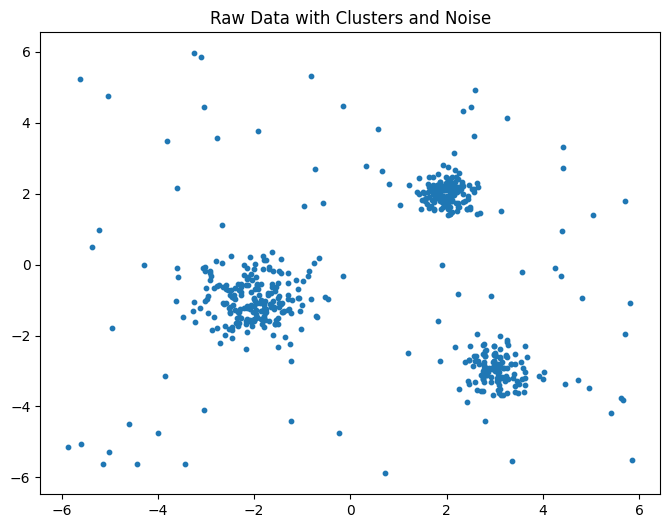

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cluster1 = np.random.randn(150, 2) * 0.3 + np.array([2, 2]) # tight density

cluster2 = np.random.randn(200, 2) * 0.6 + np.array([-2, -1]) # wide density

cluster3 = np.random.randn(120, 2) * 0.4 + np.array([3, -3]) # moderate density

noise = np.random.uniform(low=-6, high=6, size=(80, 2) ) # uniform noise

# combine everything
X = np.vstack((cluster1, cluster2, cluster3, noise))

print("Dataset shape:", X.shape)

# visualize raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title('Raw Data with Clusters and Noise')
plt.show()

In [2]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def region_query(X, point_idx, eps):
    neighbors = []
    for i in range(len(X)):
        if euclidean_distance(X[point_idx], X[i]) < eps:
            neighbors.append(i)
    return neighbors        

In [3]:
# Quick sanity test
test_eps = 0.5
neighbors_of_0 = region_query(X, 0, test_eps)

print("Number of neighbors for point 0:", len(neighbors_of_0))

Number of neighbors for point 0: 109


In [4]:
MinPts = 4 # {MinPts ≥ (d+1)} where d is the number of dimensions (here d=2)

k_distances = []

for i in range(len(X)):
    distances = []
    for j in range(len(X)):
        distances.append(euclidean_distance(X[i], X[j]))
    
    distances.sort()
    k_distances.append(distances[MinPts])  # 4th nearest (index 4 because self=0)

k_distances = np.array(k_distances)
k_distances_sorted = np.sort(k_distances)

print("First 10 sorted k-distances:")
print(k_distances_sorted[:10])

print("Last 10 sorted k-distances:")
print(k_distances_sorted[-10:])

First 10 sorted k-distances:
[0.03104536 0.03709821 0.04151991 0.04436055 0.04855811 0.05005453
 0.05059901 0.05338888 0.05338888 0.05443785]
Last 10 sorted k-distances:
[2.00689252 2.0975921  2.15701389 2.23716627 2.29216795 2.34117566
 2.43439781 2.59705546 2.63058551 2.6604433 ]


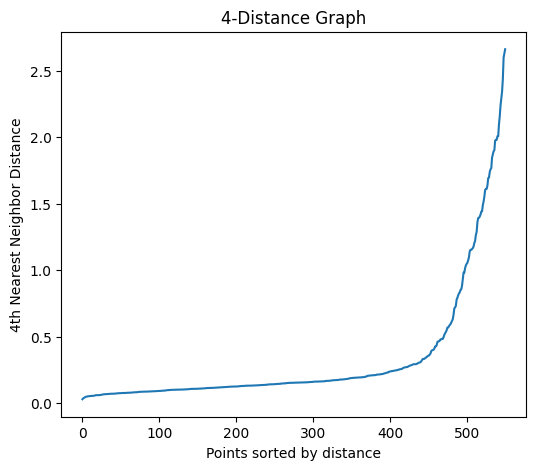

In [5]:
plt.figure(figsize=(6,5))
plt.plot(k_distances_sorted)
plt.title("4-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("4th Nearest Neighbor Distance")
plt.show()

> So we will choose:        
ε=0.5           
MinPts=4

In [6]:
eps = 0.5
MinPts = 4

labels = np.full(len(X), -1)   # -1 = noise initially
visited = np.zeros(len(X), dtype=bool)

cluster_id = 0

In [7]:
def expand_cluster(point_idx, neighbors, cluster_id):
    labels[point_idx] = cluster_id

    i = 0
    while i < len(neighbors):
        neighbor_idx = neighbors[i]

        if not visited[neighbor_idx]:
            visited[neighbor_idx] = True
            neighbor_neighbors = region_query(X, neighbor_idx, eps)

            if len(neighbor_neighbors) >= MinPts:
                neighbors += neighbor_neighbors  # density expansion

        if labels[neighbor_idx] == -1:
            labels[neighbor_idx] = cluster_id

        i += 1


In [8]:
for i in range(len(X)):

    if visited[i]:
        continue

    visited[i] = True
    neighbors = region_query(X, i, eps)

    if len(neighbors) < MinPts:
        labels[i] = -1  # remains noise
    else:
        expand_cluster(i, neighbors, cluster_id)
        cluster_id += 1

In [9]:
print("Number of clusters found:", cluster_id)
print("Noise points:", np.sum(labels == -1))

Number of clusters found: 3
Noise points: 66


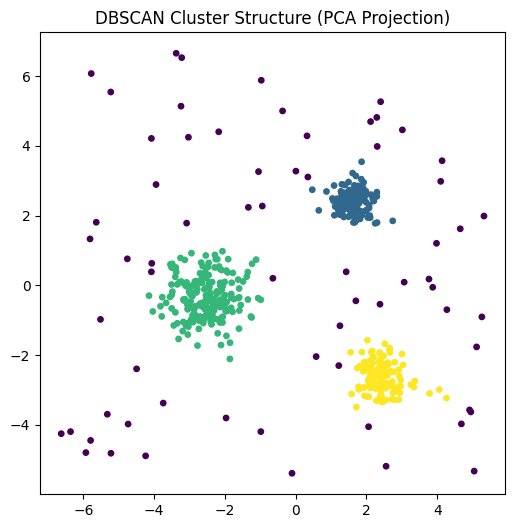

Explained variance ratio: [0.55994007 0.44005993]


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=15)
plt.title("DBSCAN Cluster Structure (PCA Projection)")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## working on real data

In [22]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

data = load_iris()
X_real = data.data # only features, no labels

print("Real dataset shape:", X_real.shape)
print("Unscaled shape:", X_real.shape)

Real dataset shape: (150, 4)
Unscaled shape: (150, 4)


In [23]:
# Standardize features
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)

print("Scaled shape:", X_real_scaled.shape)

Scaled shape: (150, 4)


MinPts ≥ d+1
> MinPts ≥ 5  as d=4 

In [33]:
MinPts = 5

k_distances = []

for i in range(len(X_real_scaled)):
    distances = []
    for j in range(len(X_real_scaled)):
        distances.append(euclidean_distance(X_real_scaled[i], X_real_scaled[j]))
    
    distances.sort()
    k_distances.append(distances[MinPts])  # index 31

k_distances = np.array(k_distances)
k_distances_sorted = np.sort(k_distances)

print("First 10 sorted k-distances:")
print(k_distances_sorted[:10])

print("Last 10 sorted k-distances:")
print(k_distances_sorted[-10:])

First 10 sorted k-distances:
[0.26013882 0.2662756  0.2662756  0.27119749 0.28389113 0.29154628
 0.29154628 0.2970349  0.2970349  0.2970349 ]
Last 10 sorted k-distances:
[0.95549527 0.96698971 1.08299431 1.08458812 1.1230724  1.12307389
 1.21236159 1.65284675 1.78540247 1.90119515]


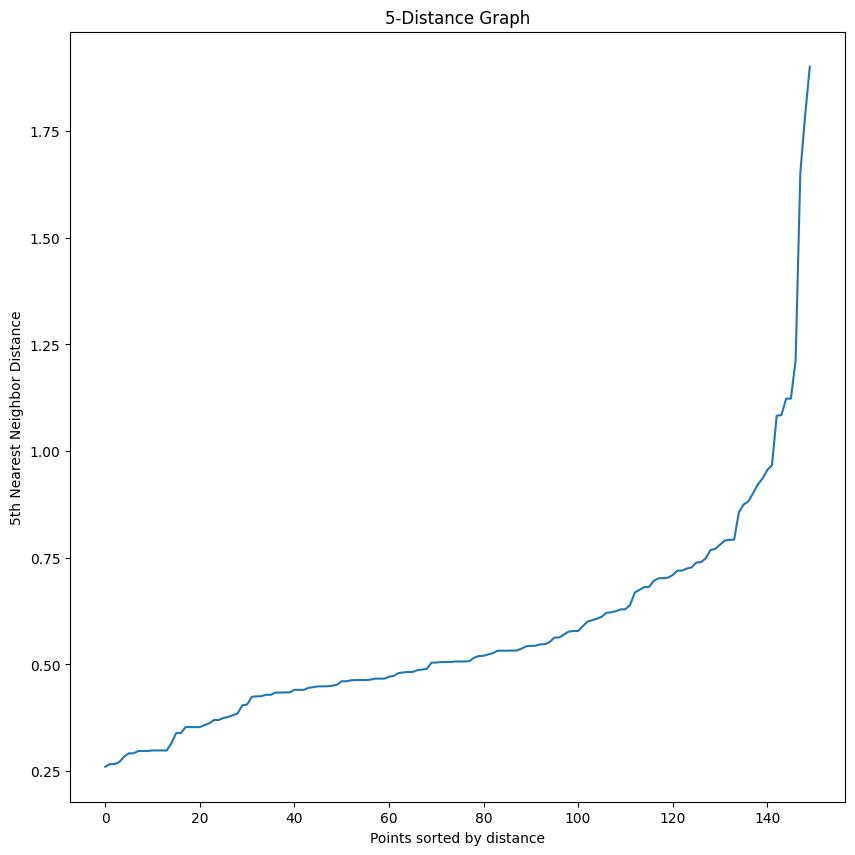

In [34]:
plt.figure(figsize=(10,10))
plt.plot(k_distances_sorted)
plt.title("5-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()

>ε ≈ [0.85, 0.95, 1.05]

>MinPts = 5

In [35]:
def dbscan(X, eps, MinPts):
    
    labels = np.full(len(X), -1)
    visited = np.zeros(len(X), dtype=bool)
    cluster_id = 0

    def region_query(point_idx):
        neighbors = []
        for i in range(len(X)):
            if euclidean_distance(X[point_idx], X[i]) <= eps:
                neighbors.append(i)
        return neighbors

    def expand_cluster(point_idx, neighbors, cluster_id):
        labels[point_idx] = cluster_id
        i = 0

        while i < len(neighbors):
            neighbor_idx = neighbors[i]

            if not visited[neighbor_idx]:
                visited[neighbor_idx] = True
                neighbor_neighbors = region_query(neighbor_idx)

                if len(neighbor_neighbors) >= MinPts:
                    neighbors += neighbor_neighbors

            if labels[neighbor_idx] == -1:
                labels[neighbor_idx] = cluster_id

            i += 1

    for i in range(len(X)):

        if visited[i]:
            continue

        visited[i] = True
        neighbors = region_query(i)

        if len(neighbors) >= MinPts:
            expand_cluster(i, neighbors, cluster_id)
            cluster_id += 1

    return labels, cluster_id

In [36]:
# Run DBSCAN

eps_values = [0.85, 0.95, 1.05]

for eps in eps_values:
    labels_test, cluster_count = dbscan(X_real_scaled, eps=eps, MinPts=MinPts)
    noise_count = np.sum(labels_test == -1)
    print(f"eps={eps} | clusters={cluster_count} | noise={noise_count}")

eps=0.85 | clusters=2 | noise=4
eps=0.95 | clusters=2 | noise=3
eps=1.05 | clusters=2 | noise=3


**DBSCAN detects density separation, not label separation.**

If two classes overlap in feature space, DBSCAN will not magically separate them.

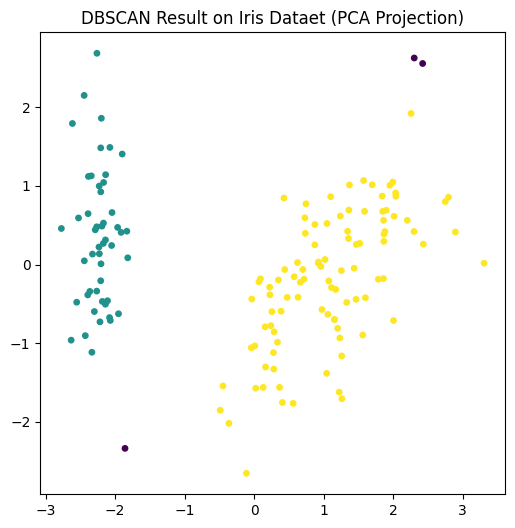

Explained variance ratio: [0.72962445 0.22850762]


In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca_real = pca.fit_transform(X_real_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_pca_real[:,0], X_pca_real[:,1], c=labels_test, s=15)
plt.title("DBSCAN Result on Iris Dataet (PCA Projection)")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

- so they capture ~94% of the total variance

> Synthetic 2D → strong density contrast → DBSCAN works well.

> 30D real data → weak density separation → DBSCAN behaves like anomaly detection.

## varying PCA

In [41]:
from sklearn.decomposition import PCA

def pca_reduce(X, k):
    # ensure n_components does not exceed allowed maximum
    max_k = min(X.shape[0], X.shape[1])
    if k > max_k:
        print(f"Requested k={k} > max allowable components={max_k}. Using k={max_k} instead.")
        k = max_k
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X)
    return X_reduced, pca.explained_variance_ratio_.sum()

for k in [2, 5]:
    X_k, var_retained = pca_reduce(X_real_scaled, k)
    print(f"k = {k}, variance retained = {var_retained:.4f}")

k = 2, variance retained = 0.9581
Requested k=5 > max allowable components=4. Using k=4 instead.
k = 5, variance retained = 1.0000


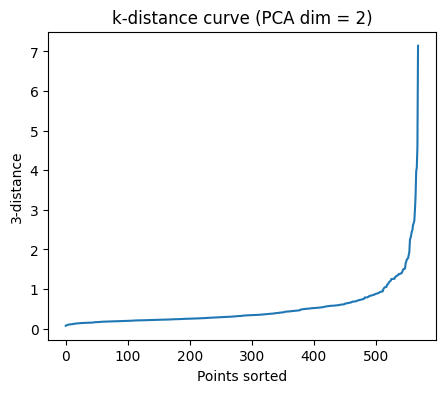

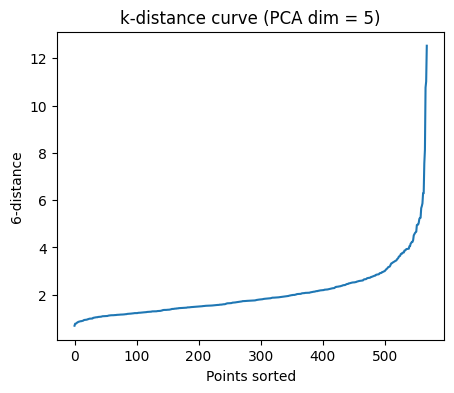

In [19]:
def compute_k_distance_curve(X, MinPts):
    k_distances = []
    for i in range(len(X)):
        distances = []
        for j in range(len(X)):
            distances.append(euclidean_distance(X[i], X[j]))
        distances.sort()
        k_distances.append(distances[MinPts])
    return np.sort(np.array(k_distances))


for k in [2, 5]:
    X_k, _ = pca_reduce(X_real_scaled, k)
    MinPts_k = k + 1
    k_dist_sorted = compute_k_distance_curve(X_k, MinPts_k)
    
    plt.figure(figsize=(5,4))
    plt.plot(k_dist_sorted)
    plt.title(f"k-distance curve (PCA dim = {k})")
    plt.xlabel("Points sorted")
    plt.ylabel(f"{MinPts_k}-distance")
    plt.show()

In [20]:
X_5D, _ = pca_reduce(X_real_scaled, 5)
MinPts_5D = 6

eps_values = [2.5, 3.0, 3.5, 4.0, 4.5]

for eps in eps_values:
    labels_5D, cluster_count = dbscan(X_5D, eps, MinPts_5D)
    noise_count = np.sum(labels_5D == -1)
    print(f"eps={eps} | clusters={cluster_count} | noise={noise_count}")

eps=2.5 | clusters=1 | noise=62
eps=3.0 | clusters=1 | noise=40
eps=3.5 | clusters=1 | noise=22
eps=4.0 | clusters=1 | noise=13
eps=4.5 | clusters=1 | noise=8
